# Reproducing the Phenobase flower ensemble on herbarium specimens

**Paper:** Erin L. Grady, Raphael LaFrance, Daijiang Li, Russell Dinnage, Ellen G. Denny, John Deck, Robert P. Guralnick (2026). *Petal to the metal: The slow road to automating large-scale phenology labeling for herbarium specimens.* Applications in Plant Sciences 14(3):e70085. DOI: [10.1002/aps3.70085](https://doi.org/10.1002/aps3.70085) (PMCID PMC13628181).

**What this notebook does (minimal reproduction):** the paper labels 22.4M herbarium images for open-flower presence with an ensemble of three fine-tuned ImageNet-pretrained models — `vit_384_lg` (MSE loss), `vit_384_lg` (cross-entropy) and `EffNet-CNN` 528 (regression) — combined by a hard two-thirds vote after per-model threshold moving. We run the authors' published checkpoints (Zenodo record 17079402, tag `v1.0.0` of [rafelafrance/phenobase](https://github.com/rafelafrance/phenobase), commit `10d7e259`) on a small balanced sample of the held-out test set (Zenodo record 17675089) and compare the ensemble verdict against the expert labels.

**Expected result:** on the full 1,442-image test split the paper reports 96.3% accuracy for present and 86.8% for absent open flowers (ensemble recall 0.964 / precision 0.922, per the authors' `best_3combo_fract.json`); on our small sample we expect agreement of roughly this order, not an exact match.

**Runtime:** select **GPU (T4)**. The weight archive is ~7.2 GB (the download in step 2 takes roughly 30–40 minutes); inference itself is light.

**日本語:** このノートブックは、標本画像に花が「ある/ない/判断不能」を判定する3モデル アンサンブル（閾値移動後の2/3多数決）を、著者公開の重みとテスト画像の一部で再現します。重みは約7.2 GB のため、GPU ランタイムで数十分のダウンロードが必要です。

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers", "torch", "torchvision", "pandas"], check=True)

import hashlib, io, json, csv, tarfile, time, zipfile

import hashlib, io, json, csv, tarfile, time, zipfile
from collections import Counter
from pathlib import Path

import requests
import torch
from PIL import Image
from torchvision.transforms import v2
from transformers import AutoModelForImageClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
assert DEVICE == "cuda", "This reproduction needs a GPU runtime (Runtime > Change runtime type > T4 GPU)."

device: cuda


## Step 0 — Fetch the ensemble definition (thresholds + checkpoint names)

Zenodo record **17079402** holds the published ensemble: a small JSON with the three checkpoints, their moved thresholds (`threshold_low` / `threshold_high`) and `vote_threshold = 2`, plus one ~7.2 GB `.tgz` with the weights. We fetch and checksum the JSON first; the paper's held-out metrics in it (accuracy 0.9266 on the 1,321 of 1,442 records the ensemble could vote on, recall 0.9636) are what the paper's 96.3% present-accuracy claim rests on.

**日本語:** まずアンサンブル定義（各モデルの閾値と2票制）を Zenodo から取得し、MD5 で検証します。

In [ ]:
BASE = Path("/content/phenobase"); BASE.mkdir(exist_ok=True)

ZENODO_WEIGHTS = "https://zenodo.org/api/records/17079402"
rec = requests.get(ZENODO_WEIGHTS, timeout=60).json()
wfiles = {f["key"]: f for f in rec["files"]}

jmeta = wfiles["phenobase_flower_ensemble_2025-05-08.json"]
jdata = requests.get(jmeta["links"]["self"], timeout=60).content
assert hashlib.md5(jdata).hexdigest() == jmeta["checksum"].split(":")[1], "ensemble JSON md5 mismatch"
(BASE / "ensemble.json").write_bytes(jdata)
ENS = json.loads(jdata)
print(json.dumps({k: ENS[k] for k in ("combo", "accuracy", "recall", "precision", "count", "total_records")}, indent=1))
for c in ENS["checkpoints"]:
    print(c["checkpoint"], "thresholds:", c["threshold_low"], c["threshold_high"])
print("vote_threshold:", ENS["args"]["vote_threshold"])

{
 "combo": [
  "vit_384_lg_flowers_f1_slurm_sl/checkpoint-9450",
  "vit_384_lg_flowers_f1_a/checkpoint-19199",
  "effnet_528_flowers_reg_f1_a/checkpoint-17424"
 ],
 "accuracy": 0.9265707797123391,
 "recall": 0.9635922330097088,
 "precision": 0.9221835075493612,
 "count": 1321,
 "total_records": 1442
}
vit_384_lg_flowers_f1_slurm_sl/checkpoint-9450 thresholds: 0.05 0.9500000000000004
vit_384_lg_flowers_f1_a/checkpoint-19199 thresholds: 0.5 0.7000000000000002
effnet_528_flowers_reg_f1_a/checkpoint-17424 thresholds: 0.5 0.7000000000000002
vote_threshold: 2


## Step 1 — Download the weight archive and extract only the three checkpoints

The archive contains the ensemble's checkpoint directories under `best_3combo_fract/` (directory names use `_` where the JSON uses `/`). We stream the ~7.2 GB `.tgz` to disk while computing its MD5, verify against Zenodo's checksum, then extract **only** the members belonging to the three checkpoints used by the ensemble — a partial, revision-pinned retrieval inside Colab.

**日本語:** 約7.2 GB の `.tgz` をストリーミング保存しながら MD5 を計算し、Zenodo のチェックサムと照合します。その後、アンサンブルが使う3つのチェックポイントのみを展開します（この工程で約30–40分かかります）。

In [ ]:
tmeta = wfiles["phenobase_flower_ensemble_2025-05-08.tgz"]
tgz = BASE / "phenobase_flower_ensemble_2025-05-08.tgz"
if True:
    h = hashlib.md5()
    t0 = time.time()
    with tgz.open("wb") as fo, requests.get(tmeta["links"]["self"], stream=True, timeout=(30, 120)) as r:
        r.raise_for_status()
        for chunk in r.iter_content(1 << 22):
            fo.write(chunk)
            h.update(chunk)
    print(f"downloaded in {time.time()-t0:.0f}s")
assert h.hexdigest() == tmeta["checksum"].split(":")[1], "weight tgz md5 mismatch"
print("weight tgz md5 OK")

WANT = [c["checkpoint"].replace("/", "_") for c in ENS["checkpoints"]]
MODELS_DIR = BASE / "best_3combo_fract"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
if not any(MODELS_DIR.iterdir()):
    with tarfile.open(tgz, "r:gz") as tf:
        n = 0
        for m in tf:
            if m.isfile() and any(w in m.name for w in WANT):
                out = BASE / m.name
                out.parent.mkdir(parents=True, exist_ok=True)
                with out.open("wb") as fo:
                    fo.write(tf.extractfile(m).read())
                n += 1
    print(f"extracted {n} checkpoint files")
for p in sorted(MODELS_DIR.rglob("*")):
    if p.is_file():
        print(f"{p.stat().st_size/1e6:9.1f} MB  {p.relative_to(BASE)}")

downloaded in 1280s
weight tgz md5 OK
      0.0 MB  best_3combo_fract/effnet_528_flowers_reg_f1_a_checkpoint-17424/config.json
    164.0 MB  best_3combo_fract/effnet_528_flowers_reg_f1_a_checkpoint-17424/model.safetensors
    326.4 MB  best_3combo_fract/effnet_528_flowers_reg_f1_a_checkpoint-17424/optimizer.pt
      0.0 MB  best_3combo_fract/effnet_528_flowers_reg_f1_a_checkpoint-17424/rng_state.pth
      0.0 MB  best_3combo_fract/effnet_528_flowers_reg_f1_a_checkpoint-17424/scheduler.pt
      0.1 MB  best_3combo_fract/effnet_528_flowers_reg_f1_a_checkpoint-17424/trainer_state.json
      0.0 MB  best_3combo_fract/effnet_528_flowers_reg_f1_a_checkpoint-17424/training_args.bin
      0.0 MB  best_3combo_fract/vit_384_lg_flowers_f1_a_checkpoint-19199/config.json
   1214.8 MB  best_3combo_fract/vit_384_lg_flowers_f1_a_checkpoint-19199/model.safetensors
   2429.9 MB  best_3combo_fract/vit_384_lg_flowers_f1_a_checkpoint-19199/optimizer.pt
      0.0 MB  best_3combo_fract/vit_384_lg_flowers_f1_

## Step 2 — Download the held-out test images and the expert labels

Zenodo record **17675089** holds the paper's image datasets; we take `phenobase_test_data.zip` (232 MB, 1,800 images = the held-out test split) and verify its MD5. Expert labels come from the authors' `datasets/splits_2025-04-22.csv` at the pinned commit `10d7e259` (the `flowers` column: `1` = open flowers present, `0` = absent, `U` = expert unknown, excluded). This is a data file, so it is fetched here in Colab, never on the authoring host.

**日本語:** テスト画像 232 MB（MD5 検証済み）と、 pinned コミットの専門家ラベル CSV を Colab 内で取得します。

In [ ]:
ZENODO_DATA = "https://zenodo.org/api/records/17675089"
drec = requests.get(ZENODO_DATA, timeout=60).json()
dfiles = {f["key"]: f for f in drec["files"]}

zmeta = dfiles["phenobase_test_data.zip"]
zpath = BASE / "phenobase_test_data.zip"
h = hashlib.md5()
with zpath.open("wb") as fo, requests.get(zmeta["links"]["self"], stream=True, timeout=(30, 120)) as r:
    r.raise_for_status()
    for chunk in r.iter_content(1 << 20):
        fo.write(chunk)
        h.update(chunk)
assert h.hexdigest() == zmeta["checksum"].split(":")[1], "test zip md5 mismatch"
print("test zip md5 OK")

PINNED_COMMIT = "10d7e2596a0037e20eba1a303c4ed73e0ec68e79"
csv_url = f"https://raw.githubusercontent.com/rafelafrance/phenobase/{PINNED_COMMIT}/datasets/splits_2025-04-22.csv"
csv_path = BASE / "splits_2025-04-22.csv"
csv_path.write_bytes(requests.get(csv_url, timeout=120).content)

LABELS = {}
with csv_path.open() as f:
    for row in csv.DictReader(f):
        if row["split"] == "test" and row["flowers"] in ("0", "1"):
            LABELS[Path(row["file"]).stem] = int(row["flowers"])
print("test-split expert labels:", len(LABELS), "(present:", sum(LABELS.values()), "absent:", len(LABELS)-sum(LABELS.values()), ")")

with zipfile.ZipFile(zpath) as zf:
    ZNAMES = [n for n in zf.namelist() if n.endswith(".jpg")]
    SAMPLE_DIR = BASE / "sample"; SAMPLE_DIR.mkdir(exist_ok=True)
    for n in ZNAMES:
        (SAMPLE_DIR / Path(n).name).write_bytes(zf.read(n))
print("test images extracted:", len(ZNAMES))

test zip md5 OK


test-split expert labels: 1442 (present: 878 absent: 564 )


test images extracted: 1801


## Step 3 — Load the three published checkpoints

Each checkpoint is a Hugging Face `AutoModelForImageClassification` directory, exactly as the authors' `model_infer.py` consumes them (`--checkpoint <dir>`). The two ViT models are 2-class single-label classifiers (score = softmax of the positive class, image size 384); the EfficientNet is a regression model (score = sigmoid of the single logit, image size 528). All use ImageNet normalization, per the authors' `pylib/inference.py`.

**日本語:** 3つのチェックポイントを著者のコードと同じ前処理（リサイズ + ImageNet 正規化）で読み込みます。ViT×2 は 2 クラス分類（softmax の陽性スコア）、EffNet は回帰（sigmoid）です。

In [ ]:
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

def checkpoint_dir(ckpt_name):
    hits = list((BASE / "best_3combo_fract").glob(f"*{ckpt_name.replace('/', '_')}*"))
    assert hits, f"checkpoint not found: {ckpt_name}"
    return hits[0]

MODELS = []
for c in ENS["checkpoints"]:
    d = checkpoint_dir(c["checkpoint"])
    model = AutoModelForImageClassification.from_pretrained(str(d))
    nlab = int(model.config.num_labels)
    size = int(getattr(model.config, "image_size", None) or json.loads((d / "config.json").read_text()).get("image_size", 384))
    model = model.to(DEVICE).eval()
    MODELS.append({"name": d.name, "model": model, "num_labels": nlab,
                   "size": size, "low": c["threshold_low"], "high": c["threshold_high"]})
    print(f"loaded {d.name}: num_labels={nlab}, image_size={size}, thresholds=({c['threshold_low']}, {c['threshold_high']})")

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

loaded vit_384_lg_flowers_f1_slurm_sl_checkpoint-9450: num_labels=2, image_size=384, thresholds=(0.05, 0.9500000000000004)


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

loaded vit_384_lg_flowers_f1_a_checkpoint-19199: num_labels=1, image_size=384, thresholds=(0.5, 0.7000000000000002)


Loading weights:   0%|          | 0/986 [00:00<?, ?it/s]

loaded effnet_528_flowers_reg_f1_a_checkpoint-17424: num_labels=1, image_size=528, thresholds=(0.5, 0.7000000000000002)


## Step 4 — Run the ensemble on a balanced test sample and vote

We score up to 30 present and 30 absent specimens from the held-out split. Per model: score < `threshold_low` → vote 0, score ≥ `threshold_high` → vote 1, otherwise the model abstains (`None`); the ensemble winner needs **2 of 3** votes, otherwise the specimen is *equivocal*. This mirrors the authors' `ensemble_vote.py` and `pylib/inference.py` exactly.

**日本語:** present/absent 各30枚のテスト標本でスコアを計算し、閾値投票（2/3 多数決、欠票あり）を行います。著者の `ensemble_vote.py` のロジックと同じです。

In [ ]:
import random
random.seed(0)

present = [s for s, l in LABELS.items() if l == 1 and (BASE / "sample" / f"{s}.jpg").exists()]
absent  = [s for s, l in LABELS.items() if l == 0 and (BASE / "sample" / f"{s}.jpg").exists()]
SAMPLE = random.sample(present, min(30, len(present))) + random.sample(absent, min(30, len(absent)))
print(f"sample: {len(SAMPLE)} specimens ({sum(LABELS[s] for s in SAMPLE)} present)")

def xform(size):
    return v2.Compose([
        v2.Resize((size, size)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

def model_score(m, img):
    x = xform(m["size"])(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = m["model"](x)
    if m["num_labels"] == 1:  # regression -> sigmoid(logit)
        return torch.sigmoid(out.logits)[0, 0].item()
    return torch.softmax(out.logits, dim=1)[0, 1].item()

VOTE_THRESHOLD = int(ENS["args"]["vote_threshold"])
results = []
t0 = time.time()
for stem in SAMPLE:
    img = Image.open(BASE / "sample" / f"{stem}.jpg").convert("RGB")
    scores, votes = [], []
    for m in MODELS:
        s = model_score(m, img)
        scores.append(s)
        votes.append(0 if s < m["low"] else (1 if s >= m["high"] else None))
    top = Counter(votes).most_common()
    winner = top[0][0] if (top[0][0] is not None and top[0][1] >= VOTE_THRESHOLD) else None
    results.append({"id": stem, "expected": LABELS[stem], "winner": winner,
                    **{f"score_{m['name'].split('_checkpoint')[0]}": s for m, s in zip(MODELS, scores)}})
print(f"inference done in {time.time()-t0:.0f}s")

import pandas as pd
df = pd.DataFrame(results)
df.to_csv(BASE / "ensemble_votes.csv", index=False)
df.head()

sample: 60 specimens (30 present)


inference done in 20s


,id,expected,winner,score_vit_384_lg_flowers_f1_slurm_sl,score_vit_384_lg_flowers_f1_a,score_effnet_528_flowers_reg_f1_a
0,1039023699_1,1,1.0,0.999998,0.722037,0.722692
1,f6a4e84e-e36f-4a85-b04b-3b3da087b39e,1,1.0,0.995705,0.700448,0.648708
2,9d4443da-c3d8-4010-86bb-e5a95d7b9221,1,1.0,0.999995,0.717986,0.722537
3,f5f85b58-c494-48a6-8145-d602e60ba31e,1,1.0,0.999981,0.709689,0.724298
4,3f3a6a9c-914d-49cb-a63c-e51f254a43b6,1,1.0,0.999985,0.719146,0.724036


## Step 5 — Compare the reproduced ensemble with the paper's held-out accuracy

The paper (RESULTS, *Model fitting and validation*) reports 96.3% accuracy for present and 86.8% for absent open flowers on the full held-out test set; the authors' JSON records ensemble recall 0.9636 / precision 0.9222 on the 1,321 of 1,442 records that received two votes. We compute the same statistics on our 60-specimen sample. With so few images these are noisy estimates — we expect them to be of the same order, not identical.

**日本語:** 論文の held-out 精度（present 96.3% / absent 86.8%）と、60標本の再現結果を比較します。サンプルが小さいため一致の精度は限られます。

voted 58/60; overall accuracy 0.931; present 0.966; absent 0.897
paper (full test set): present 0.963, absent 0.868; authors' JSON accuracy 0.9266 on 1321/1442


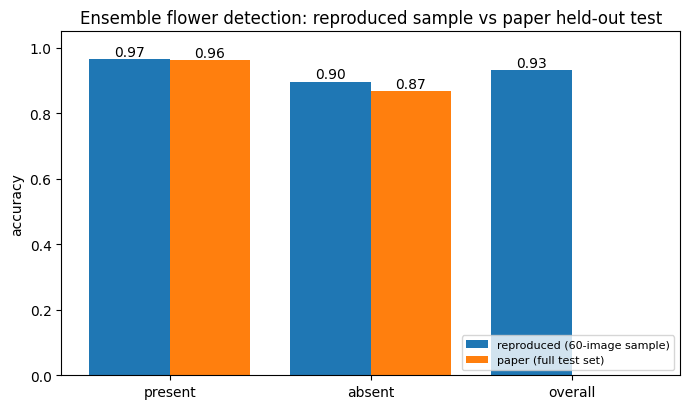

In [ ]:
voted = df[df["winner"].notna()]
correct = (voted["winner"] == voted["expected"])
acc = correct.mean()
acc_present = correct[voted["expected"] == 1].mean()
acc_absent = correct[voted["expected"] == 0].mean()
print(f"voted {len(voted)}/{len(df)}; overall accuracy {acc:.3f}; present {acc_present:.3f}; absent {acc_absent:.3f}")
print(f"paper (full test set): present 0.963, absent 0.868; authors' JSON accuracy 0.9266 on 1321/1442")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ["present", "absent", "overall"]
repro = [acc_present, acc_absent, acc]
paper = [0.963, 0.868, None]
xs = range(len(bars))
ax.bar([x - 0.2 for x in xs], [r if r == r else 0 for r in repro], width=0.4, label="reproduced (60-image sample)")
ax.bar([x + 0.2 for x in xs], [p if p else 0 for p in paper], width=0.4, label="paper (full test set)")
for x, r in zip(xs, repro):
    if r == r:
        ax.text(x - 0.2, r + 0.01, f"{r:.2f}", ha="center")
for x, p in zip(xs, paper):
    if p:
        ax.text(x + 0.2, p + 0.01, f"{p:.2f}", ha="center")
ax.set_ylim(0, 1.05); ax.set_xticks(list(xs)); ax.set_xticklabels(bars)
ax.set_ylabel("accuracy")
ax.set_title("Ensemble flower detection: reproduced sample vs paper held-out test")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(BASE / "accuracy_comparison.png", dpi=120)
plt.show()

## Step 6 — Look at a specimen and its ensemble verdict

A herbarium specimen from the held-out set, with each model's score, the thresholded votes and the final ensemble verdict versus the expert label. Remember that the models were trained on 528/384-px resized sheets — the display here is only for orientation.

**日本語:** テスト標本の1点について、各モデルのスコア・投票・アンサンブル判定と専門家ラベルを並べて表示します。

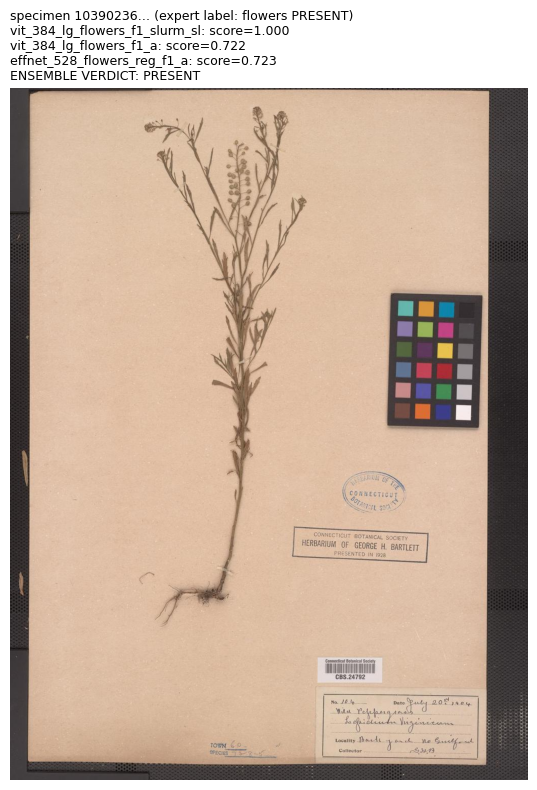

In [ ]:
row = df.iloc[0]
img = Image.open(BASE / "sample" / f"{row['id']}.jpg").convert("RGB")
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
ax.axis("off")
lines = [f"specimen {row['id'][:8]}… (expert label: {'flowers PRESENT' if row['expected']==1 else 'flowers ABSENT'})"]
for m in MODELS:
    col = f"score_{m['name'].split('_checkpoint')[0]}"
    lines.append(f"{m['name'].split('_checkpoint')[0]}: score={row[col]:.3f}")
verdict = {1: "PRESENT", 0: "ABSENT", None: "EQUIVOCAL"}[row["winner"]]
lines.append(f"ENSEMBLE VERDICT: {verdict}")
ax.set_title("\n".join(lines), fontsize=9, loc="left")
fig.tight_layout()
fig.savefig(BASE / "specimen_verdict.png", dpi=120)
plt.show()

## Limitations and notes / 制限と注記

- **Scope.** This reproduces inference + thresholded voting only, on a small sample; it does not retrain the models (the paper trained on one A100 for ≥200 epochs) nor re-assemble the 22.4M-image GBIF corpus.
- **Sample noise.** 60 specimens give wide confidence intervals; the full test split (1,442 images, 232 MB zip) can be substituted by removing the sampling step.
- **Sources.** Weights + thresholds: Zenodo [17079402](https://doi.org/10.5281/zenodo.17079402) (md5-verified); data: Zenodo [17675089](https://doi.org/10.5281/zenodo.17675089); code/labels: [rafelafrance/phenobase](https://github.com/rafelafrance/phenobase) @ `10d7e259` (MIT). Paper: 10.1002/aps3.70085.
- **日本語:** 本ノートブックは推論と閾値投票の小規模再現であり、再学習や GBIF コーパス全体の再構築は行いません。重み・閾値は Zenodo 17079402、テスト画像は Zenodo 17675089、コードは rafelafrance/phenobase の pinned コミットに基づきます。